# 03 — Endogeneity and instruments, live

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jean-jsj/CARD/blob/main/examples/03_endogeneity_and_instruments.ipynb)

CARD's central design: cells come in **pairs that differ by one constant**. The
endogeneity-on cell couples discount depth to a hidden demand shock; its control
cell is generated from byte-identical random draws with the coupling set to zero.
Any change in an estimator's error between the pair is caused by the coupling
alone.

This notebook fits two of the shipped reference estimators — the **naive** corner
(no instrument) and the **instrumented** corner (2SLS-style control function on
`supply_cost_proxy`) — on both cells of the log-log mini pair, and shows:

1. in the endogeneity-on cell, naive and IV elasticities disagree;
2. in the control cell, they roughly agree;
3. scored on the headline scenario, the naive corner's bias moves with the knob
   and the instrumented corner's does not.

Runtime: a few minutes (it fits per-product Poisson regressions on both cells).

In [1]:
# Setup: works from a local clone or on Colab (clones the repo, no pip install needed).
import os, subprocess, sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("metrics").is_dir():
    subprocess.run(["git", "clone", "-q", "https://github.com/jean-jsj/CARD"], check=True)
    os.chdir("CARD")
elif Path.cwd().name == "examples":
    os.chdir("..")
assert Path("metrics").is_dir(), "run this notebook from the CARD repo root or on Colab"
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 11, "font.size": 10})
BLUE, GREEN, GRAY = "#2a78d6", "#008300", "#6b7280"

In [2]:
# Fetch both ~18 MB mini cells: the endogeneity-on arena cell and its control.
from huggingface_hub import snapshot_download

CELLS = {"on":  "complex_log_log_endogenous_seed001",
         "off": "complex_log_log_exogenous_seed001"}
for cell in CELLS.values():
    if not (Path("benchmark/dev_mini") / cell).exists():
        snapshot_download(repo_id="jean-jsj/CARD", repo_type="dataset",
                          allow_patterns=[f"dev_mini/{cell}/*"], local_dir="benchmark")
print("ready")

ready


## 1. Fit the naive and instrumented corners on both cells

`baselines/` ships the reference estimators behind the paper's reference grid.
For the log-log family the estimator is a per-product Poisson (PPML) count model
with store and week fixed effects; the IV corner adds a control-function residual
whose first stage regresses log price on `supply_cost_proxy`. Both consume only
`public/` files.

In [3]:
from baselines import loglog_grid

fits = {}
for knob, cell in CELLS.items():
    cell_dir = Path("benchmark/dev_mini") / cell
    train    = pd.read_csv(cell_dir / "public" / "transactions_train_public.csv")
    products = pd.read_csv(cell_dir / "public" / "products_public.csv")
    for corner, use_iv in [("naive", False), ("iv", True)]:
        fits[(knob, corner)] = loglog_grid.fit_loglog_corner(
            train, products, use_iv=use_iv, use_text=True)
        betas = [c["beta"] for c in fits[(knob, corner)]["coefs"].values()]
        print(f"endogeneity {knob:3s} | {corner:5s} | mean own-price elasticity "
              f"{np.mean(betas):+.2f}")

endogeneity on  | naive | mean own-price elasticity -2.12


endogeneity on  | iv    | mean own-price elasticity -1.84


endogeneity off | naive | mean own-price elasticity -1.65


endogeneity off | iv    | mean own-price elasticity -1.78


## 2. Where the estimates disagree

Each point below is one product: its naive estimate against its instrumented
estimate. In the endogeneity-on cell the cloud sits **below** the diagonal — the
naive estimator sees discounts co-occur with the hidden demand surge and credits
the extra volume to price, overstating how negative the elasticity is. In the
control cell the coupling is off and the cloud hugs the diagonal.

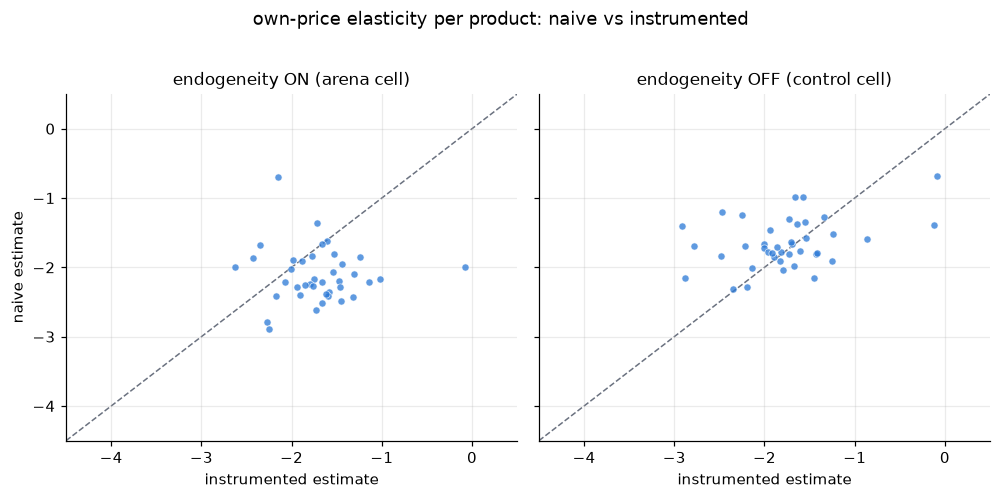

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.4), sharex=True, sharey=True)
for ax, knob, title in [(axes[0], "on", "endogeneity ON (arena cell)"),
                        (axes[1], "off", "endogeneity OFF (control cell)")]:
    naive = fits[(knob, "naive")]["coefs"]; iv = fits[(knob, "iv")]["coefs"]
    common = [p for p in naive if naive[p]["converged"] and iv[p]["converged"]]
    x = [iv[p]["beta"] for p in common]; y = [naive[p]["beta"] for p in common]
    lo, hi = -4.5, 0.5
    ax.plot([lo, hi], [lo, hi], color=GRAY, lw=1, ls="--", zorder=1)
    ax.scatter(x, y, s=22, color=BLUE, alpha=0.75, edgecolors="white", lw=0.5, zorder=2)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("instrumented estimate")
    ax.set_title(title)
axes[0].set_ylabel("naive estimate")
fig.suptitle("own-price elasticity per product: naive vs instrumented", y=1.02)
plt.tight_layout(); plt.show()

## 3. What that does to the scored headline

Now produce each corner's counterfactual predictions for the headline scenario
and score them against the hidden truth — in both cells. The exact movement of
each estimator between the control cell and the arena cell is the bias the
coupling induces.

In [5]:
import json, subprocess

bias = {}
for (knob, corner), params in fits.items():
    cell = CELLS[knob]
    cell_dir = Path("benchmark/dev_mini") / cell
    holdout = pd.read_csv(cell_dir / "public" / "transactions_holdout_context_public.csv")
    sweep   = pd.read_csv(cell_dir / "public" / "counterfactual_sweep_context_public.csv")
    products = pd.read_csv(cell_dir / "public" / "products_public.csv")

    sub_dir = Path("submissions_local") / f"ref_{corner}" / cell
    sub_dir.mkdir(parents=True, exist_ok=True)
    loglog_grid.predict_holdout_units(params, holdout).to_csv(
        sub_dir / "forecast_predictions.csv", index=False)
    loglog_grid.elasticity_matrix(params, products).to_csv(
        sub_dir / "elasticity_matrix.csv", index=False)
    loglog_grid.predict_sweep_deltas(params, sweep, holdout).to_csv(
        sub_dir / "counterfactual_deltas.csv", index=False)

    out = Path("submissions_local") / f"score_{corner}_{knob}.json"
    subprocess.run([sys.executable, "-m", "metrics.evaluate_submission",
                    "--cell-dir", str(cell_dir), "--submission-dir", str(sub_dir),
                    "--submission-name", f"ref_{corner}", "--out", str(out)],
                   check=True, capture_output=True)
    score = json.loads(out.read_text())
    bias[(knob, corner)] = score["counterfactual_prediction"]["headline"]["own_price"]["own_price_wmpe"]
    print(f"endogeneity {knob:3s} | {corner:5s} | own-price bias {bias[(knob, corner)]:+.3f}")

endogeneity on  | naive | own-price bias +0.087


endogeneity on  | iv    | own-price bias +0.096


endogeneity off | naive | own-price bias +0.421


endogeneity off | iv    | own-price bias +0.123


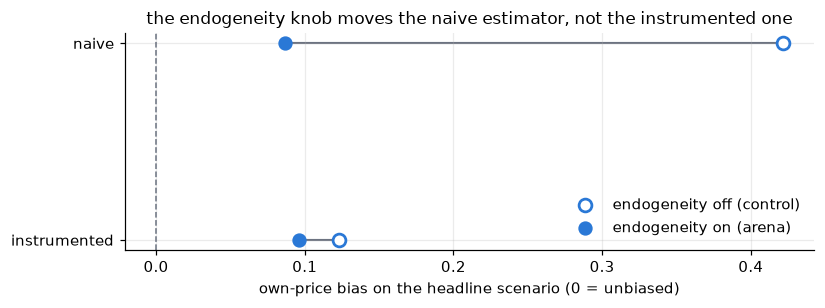

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 2.9))
rows = [("iv", "instrumented"), ("naive", "naive")]
for y, (corner, label) in enumerate(rows):
    b_off, b_on = bias[("off", corner)], bias[("on", corner)]
    ax.plot([b_off, b_on], [y, y], color=GRAY, lw=1.4, zorder=1)
    ax.scatter([b_off], [y], s=70, facecolors="white", edgecolors=BLUE, lw=1.8, zorder=2,
               label="endogeneity off (control)" if y == 0 else None)
    ax.scatter([b_on], [y], s=70, color=BLUE, zorder=3,
               label="endogeneity on (arena)" if y == 0 else None)
ax.axvline(0, color=GRAY, lw=1, ls="--")
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[1] for r in rows])
ax.set_xlabel("own-price bias on the headline scenario (0 = unbiased)")
ax.set_title("the endogeneity knob moves the naive estimator, not the instrumented one")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

Read the plot on the **movement, not the levels**. On a 10-store slice every
estimator carries a small-sample level offset (both corners sit above zero in
the control cell), and for the naive corner that offset happens to partially
cancel the confounding in the arena cell. The attributable quantity is the
*shift between the paired cells*, which share byte-identical randomness: here
the naive corner moves by roughly −0.3 when the knob turns on while the
instrumented corner barely moves — the same movement the full cells show, where
the estimation offset is gone and the naive corner lands at bias −0.23 with the
instrumented corners on the zero line. The full-cell reference numbers (and the
probit family, and the text on/off axis) are in
[docs/reference_results.html](../docs/reference_results.html).

## Bring your own model

Any estimator that emits the three CSVs can be scored the same way:

1. download a full cell: `python examples/download_data.py --cell complex_log_log_endogenous_seed001`
2. write `forecast_predictions.csv`, `elasticity_matrix.csv`,
   `counterfactual_deltas.csv` ([format](../metrics/SUBMISSION_FORMAT.md))
3. score: `python -m metrics.evaluate_all --cells-root benchmark/dev --submissions-root my_model/ --submission-name my_model --out-dir scores/`
4. submit via PR for verified eval-seed scoring ([CONTRIBUTING.md](../CONTRIBUTING.md))